# Functional Enrichment Analysis

## Objective

Differential expression analysis identified thousands of genes that differed significantly between ABC and GCB DLBCL.

However, individual genes rarely act in isolation. Instead, biological functions emerge through coordinated activity of pathways, signaling networks, and cellular programs.

The objective of this notebook is to identify biological processes and molecular pathways that distinguish ABC and GCB DLBCL using:

1. Over-Representation Analysis (ORA)
2. Gene Set Enrichment Analysis (GSEA)

These approaches help translate gene-level findings into biologically interpretable mechanisms.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import dotplot

In [2]:
dea_results = pd.read_csv("../results/tables/GSE10846_dea_results.csv", index_col=0)

expr_df = pd.read_csv("../data/processed/GSE10846_expr_matrx.csv",  index_col=0 )
meta_df = pd.read_csv("../data/processed/GSE10846_metadata.csv",  index_col=0 )

## Methodological Framework: ORA vs. GSEA

To map individual dysregulated transcripts to macroscopic biological systems, we utilized two complementary functional genomics methodologies:

1. **Over-Representation Analysis (ORA):** This approach applies a hyper-geometric test against predefined gene sets (KEGG, Gene Ontology). It relies on a user-defined threshold ($|\log_2\text{FC}| > 1.0$ and $\text{p}_{\text{adj}} < 0.05$) to isolate a discrete group of highly altered genes. While computationally clean, ORA suffers from threshold bias and ignores valuable data from transcripts that fall just below the arbitrary significance cutoff.
2. **Gene Set Enrichment Analysis (GSEA Prerank):** Instead of filtering data using arbitrary cutoffs, GSEA evaluates the entire transcriptomic spectrum. By ranking all $23,520$ genes along a continuous gradient of statistical significance and fold-change directionality, GSEA detects subtle, coordinated expression shifts across entire biochemical pathways. This allows us to capture complex systemic changes, such as metabolic rewiring or transcription factor activation networks, that ORA might miss.

## Over-Representation Analysis (ORA)

ORA tests whether predefined biological pathways contain more differentially expressed genes than expected by chance.

Genes meeting the following criteria were selected:

* Adjusted P-value < 0.05
* log2 Fold Change > 1

These genes represent transcripts strongly upregulated in ABC DLBCL relative to GCB DLBCL.

A total of 146 genes were submitted to enrichment analysis using:

* KEGG Pathways
* Gene Ontology Biological Processes


In [3]:
abc_genes = dea_results[(dea_results['padj'] < 0.05) & (dea_results['log2FC'] > 1.0)].index.tolist()

In [4]:
print(f"Feeding {len(abc_genes)} upregulated genes into Enrichment Analysis...")

Feeding 143 upregulated genes into Enrichment Analysis...


In [5]:
enr = gp.enrichr(
    gene_list=abc_genes,
    gene_sets=['KEGG_2021_Human', 'GO_Biological_Process_2023'],
    organism='human',
    outdir=None,
    cutoff=0.05
)

In [6]:
ora_results = enr.results
ora_results.sort_values(by='Adjusted P-value').head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Cytokine-cytokine receptor interaction,12/295,0.000001,0.000155,0,0,6.335824,85.204877,IL10;CXCL10;CCL8;CCL22;TNFRSF13B;IL7;IL12B;IL1...
1,KEGG_2021_Human,Viral protein interaction with cytokine and cy...,7/100,0.000008,0.000405,0,0,10.938330,128.964347,IL10;CXCL10;CCL8;CCL22;CCR7;CCL18;CCR10
107,GO_Biological_Process_2023,Response To Lipopolysaccharide (GO:0032496),9/159,0.000002,0.001122,0,0,8.824030,115.061388,IL10;CXCL10;NLRP7;EHHADH;TNIP3;IL12A;S100A9;S1...
108,GO_Biological_Process_2023,Cellular Response To Cytokine Stimulus (GO:007...,12/308,0.000002,0.001122,0,0,6.053538,78.695537,HCK;TCL1A;CCL8;CCL22;NLRP7;IL7;IL12B;CCR7;MNDA...
113,GO_Biological_Process_2023,Lymphocyte Chemotaxis (GO:0048247),5/44,0.000015,0.001817,0,0,18.411371,204.363429,CXCL10;CCL8;CCL22;GPR183;CCL18
114,GO_Biological_Process_2023,Regulation Of B Cell Proliferation (GO:0030888),5/44,0.000015,0.001817,0,0,18.411371,204.363429,IL10;TNFRSF13B;IL7;GPR183;MNDA
115,GO_Biological_Process_2023,Cytokine-Mediated Signaling Pathway (GO:0019221),10/257,0.000016,0.001817,0,0,5.969377,65.745831,CXCL10;HCK;CCL8;CCL22;IL7;IL12B;IL12A;CCL18;LI...
112,GO_Biological_Process_2023,Granulocyte Chemotaxis (GO:0071621),6/73,0.000014,0.001817,0,0,12.936050,144.758974,CXCL10;CCL8;CCL22;CCL18;S100A9;S100A8
109,GO_Biological_Process_2023,T-helper Cell Differentiation (GO:0042093),4/18,0.000007,0.001817,0,0,40.787256,483.592023,GPR183;IL12B;BATF;FOXP1
110,GO_Biological_Process_2023,Response To Molecule Of Bacterial Origin (GO:0...,6/69,0.000010,0.001817,0,0,13.760167,158.484197,IL10;EHHADH;IL12A;S100A9;S100A8;FOXP1


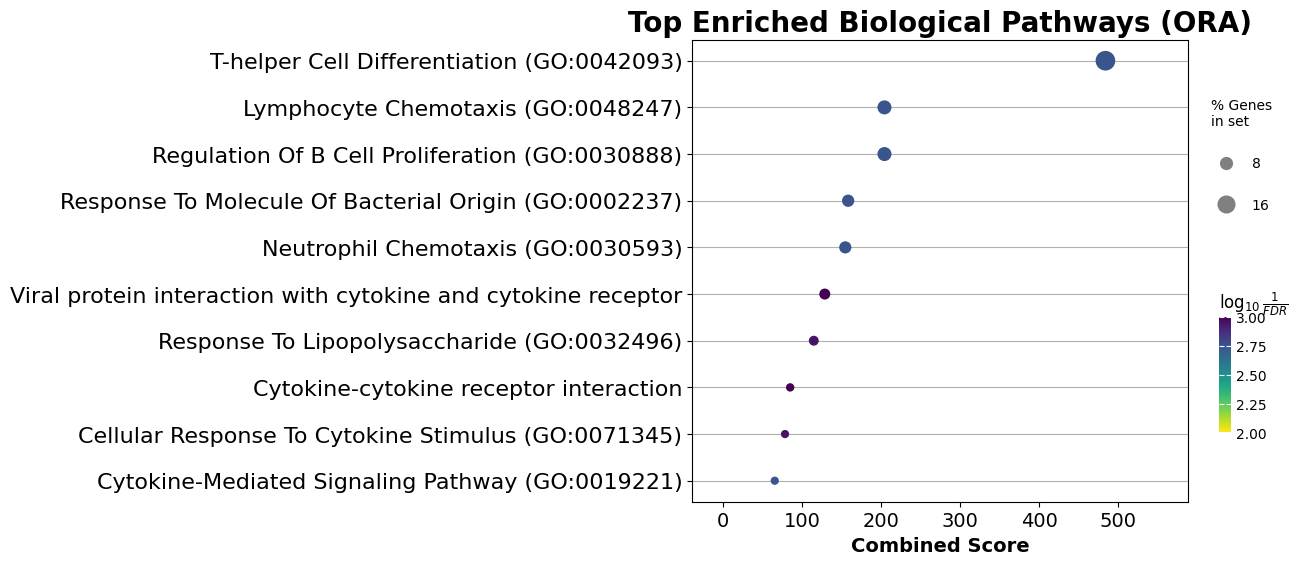

In [7]:
top_terms = (
    ora_results
    .sort_values("Adjusted P-value")
    .head(15)
)

dotplot(
    top_terms,
    column="Adjusted P-value",
    figsize=(8,6),
    title="Top Enriched Biological Pathways (ORA)"
)

plt.savefig("../results/figures/ora_pathway_dotplot.png", dpi=300)
plt.show()

## Interpretation of ORA Results

Several enriched pathways point toward enhanced immune and inflammatory signaling in ABC DLBCL.

Notable findings include:

* Cytokine-cytokine receptor interaction
* Cellular response to cytokine stimulus
* Interferon-related signaling
* T-helper cell differentiation
* Regulation of B-cell proliferation
* Chemotaxis-related pathways

These results suggest that ABC DLBCL exhibits increased immune signaling activity and inflammatory pathway engagement compared with GCB DLBCL.

The enrichment of B-cell proliferation pathways is particularly relevant because DLBCL arises from malignant B lymphocytes and subtype-specific differences in B-cell signaling are known contributors to disease biology.


In [8]:
ora_results.to_csv("../results/tables/GSE10846_ora_results.csv")

## Gene Set Enrichment Analysis (GSEA)

Unlike ORA, which uses only a subset of significant genes, GSEA evaluates the entire ranked gene list.

Genes were ranked using a metric that combines:

* Magnitude of differential expression (log2FC)
* Statistical significance

This approach allows detection of coordinated pathway-level changes even when individual genes do not pass strict significance thresholds.

Hallmark gene sets from MSigDB were used because they represent well-curated biological programs and reduce redundancy among related pathways.


In [9]:
dea_results["ranking_metric"] = (dea_results["log2FC"] * -np.log10(dea_results["padj"] + 1e-300))
ranked_genes = dea_results['ranking_metric'].sort_values(ascending=False)

In [10]:
pre_res = gp.prerank(
    rnk=ranked_genes,
    gene_sets='MSigDB_Hallmark_2020',
    organism='human',
    outdir=None,
    permutation_num=1000, 
    min_size=15,
    max_size=500,
    seed=42
)

In [11]:
gsea_results = pre_res.res2d
gsea_results.sort_values(by='NES', ascending=False).head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Myc Targets V1,0.792934,1.807344,0.001000,0.002170,0.001,79/189,12.21%,RRP9;ABCE1;ETF1;GOT2;SRM;APEX1;CANX;SNRPD1;NPM...
2,prerank,Myc Targets V2,0.812715,1.564301,0.009677,0.110658,0.093,28/57,11.31%,RRP9;SRM;NPM1;IPO4;MYC;HK2;PLK4;GRWD1;HSPE1;EX...
3,prerank,Interferon Gamma Response,0.665132,1.542558,0.005051,0.096916,0.122,59/196,7.08%,IRF4;BPGM;PIM1;IL10RA;IL7;SLAMF7;PDE4B;PNP;PTP...
4,prerank,Fatty Acid Metabolism,0.703845,1.53811,0.004878,0.075942,0.127,43/154,9.51%,EHHADH;ERP29;GLUL;UBE2L6;CD1D;ACSM3;APEX1;HSD1...
7,prerank,IL-6/JAK/STAT3 Signaling,0.706229,1.474521,0.037453,0.113262,0.224,25/87,7.32%,IL17RB;PIM1;IL7;CD44;PTPN1;CXCL10;IL10RB;CXCL1...
10,prerank,Unfolded Protein Response,0.664447,1.450541,0.024793,0.117890,0.276,32/105,7.87%,HSP90B1;NABP1;SRPRB;RRP9;MTHFD2;SPCS3;NPM1;DNA...
11,prerank,mTORC1 Signaling,0.645027,1.448027,0.021505,0.102599,0.279,40/193,7.19%,SLA;HSP90B1;PNP;POLR3G;RRP9;MTHFD2;ETF1;GCLC;C...
12,prerank,Interferon Alpha Response,0.685146,1.447569,0.024000,0.089774,0.279,23/93,7.87%,IL7;CXCL10;NMI;UBE2L6;CXCL11;RTP4;OAS1;CD47;PS...
13,prerank,Oxidative Phosphorylation,0.603275,1.397609,0.015228,0.122953,0.386,60/183,12.01%,CASP7;GOT2;NDUFV2;ETFA;ECI1;COX5A;MRPS22;UQCRF...
14,prerank,IL-2/STAT5 Signaling,0.595513,1.384741,0.018868,0.122592,0.418,26/193,3.39%,BATF;NFKBIZ;IRF4;PIM1;IL10RA;CD44;IL10;CCND2;P...


## Interpretation of GSEA Results

### GSEA Parameters
* **Enrichment Score (ES):** Reflects the degree to which a gene set is overrepresented at the extreme top or bottom of the entire ranked list.
* **Normalized Enrichment Score (NES):** Adjusts the raw ES for differences in gene set sizes, making scores directly comparable across distinct pathways. A positive NES signifies a pathway coordinated toward overexpression in the **ABC DLBCL** cohort.
* **FDR q-value:** Controls for multiple testing across all evaluated gene sets. A threshold of $\text{FDR} < 0.25$ is the standard academic convention for GSEA, though our top hits show even greater significance ($\text{FDR} < 0.05$).

### Biological programs
GSEA revealed coordinated activation of several hallmark biological programs in ABC DLBCL.

The strongest positively enriched pathways included:

* MYC Targets V1
* MYC Targets V2
* Interferon Gamma Response
* Interferon Alpha Response
* IL-6/JAK/STAT3 Signaling
* IL-2/STAT5 Signaling
* mTORC1 Signaling
* Fatty Acid Metabolism

These pathways collectively suggest that ABC DLBCL is characterized by increased cellular proliferation, inflammatory signaling, immune activation, and metabolic reprogramming.

Particularly noteworthy is the enrichment of IL-6/JAK/STAT3 and interferon signaling pathways, which are consistent with previous studies describing chronic activation of inflammatory and survival pathways in ABC DLBCL.

### Pathophysiological Relevance of Top Enriched Programs

The absolute dominance of **MYC Targets**, **IL-6/JAK/STAT3**, and **Interferon Gamma/Alpha Response** signatures in the ABC subtype validates the molecular precision of our cohort selection:

* **MYC Activation (V1/V2):** MYC is a master oncogenic transcription factor that drives continuous metabolic acceleration and cell cycle progression. Its strong positive enrichment highlights the highly proliferative nature of ABC DLBCL tumors.
* **IL-6/JAK/STAT3 Signaling:** Chronic autocrine and paracrine IL-6 signaling is a well-documented survival mechanism in ABC DLBCL. This pathway triggers downstream STAT3 phosphorylation, which blocks apoptosis and cooperates with constitutional NF-κB signaling to drive therapeutic resistance.
* **Interferon Gamma ($\text{IFN-}\gamma$) Response:** This signal reveals an inflammatory, immune-engaged microenvironmental state. While $\text{IFN-}\gamma$ classically drives anti-tumor immunity, persistent activation within ABC tumors often signals a protective microenvironmental niche, induction of immune checkpoints, or chronic immune-cell recruitment via specific chemokines.


In [12]:
gsea_results.to_csv("../results/tables/GSE10846_gsea_results.csv")

## Visualization of Leading-Edge Genes

To further investigate one of the most biologically relevant enriched pathways, genes contributing to the enrichment of the Interferon Gamma Response signature were visualized using a heatmap.

Leading-edge genes are the subset of genes that contribute most strongly to a GSEA enrichment signal.

Visualizing these genes provides insight into whether pathway enrichment reflects coordinated expression changes across individual patient samples.


In [13]:
ifn_gamma_genes = ["IRF4", "BPGM", "IL10RA", "PIM1", "PNP", "CASP7", "PDE4B", "PTPN1", "CXCL10"]

genes_to_plot = [g for g in ifn_gamma_genes if g in expr_df.index]

meta_df_sorted = meta_df.sort_values(by="Subtype")
heatmap_data = expr_df.loc[genes_to_plot, meta_df_sorted.index]

heatmap_scaled = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

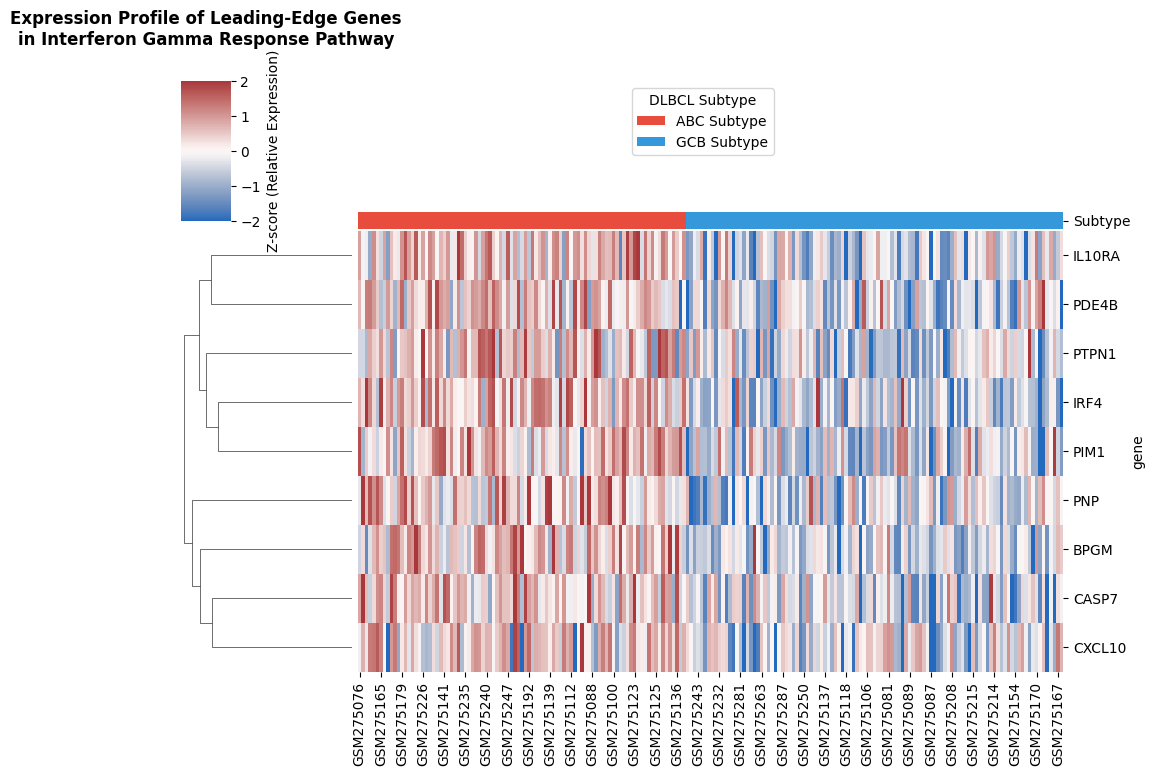

In [14]:
sample_colors = meta_df_sorted["Subtype"].map({"ABC": "#e74c3c", "GCB": "#3498db"})

g = sns.clustermap(
    heatmap_scaled,
    cmap="vlag",           
    vmin=-2, vmax=2,        
    col_colors=sample_colors,
    col_cluster=False,      
    row_cluster=True,       
    figsize=(10, 7),
    cbar_kws={'label': 'Z-score (Relative Expression)'},
    cbar_pos=(0.02, 0.8, 0.05, 0.2)
)

legend_elements = [
    Patch(facecolor='#e74c3c', label='ABC Subtype'),
    Patch(facecolor='#3498db', label='GCB Subtype')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(12, 1), title="DLBCL Subtype")

plt.title("Expression Profile of Leading-Edge Genes\nin Interferon Gamma Response Pathway", loc ='center', y=1.2,  fontsize=12, weight='bold')

plt.savefig("../results/figures/ifn_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## Interpretation

The heatmap demonstrates a striking difference in expression patterns between ABC and GCB DLBCL.

Key observations include:

* Interferon Gamma Response genes show consistently elevated expression in ABC samples.
* The same genes exhibit lower expression levels in most GCB samples.
* Samples cluster according to molecular subtype despite subtype labels not being used during gene clustering.

This pattern indicates that activation of interferon-related signaling is a coordinated feature of the ABC subtype rather than the result of isolated gene-level changes.

The heatmap therefore provides visual validation of the GSEA findings.


## Conclusions

Functional enrichment analysis revealed substantial biological differences between ABC and GCB DLBCL.

Major findings include:

1. ABC DLBCL exhibits enhanced cytokine and immune signaling activity.
2. Pathways related to B-cell proliferation and inflammatory responses are significantly enriched.
3. GSEA identified activation of MYC, interferon, JAK/STAT, and mTOR signaling programs.
4. Interferon Gamma Response genes show coordinated overexpression in ABC tumors.

Together, these results indicate that ABC DLBCL is characterized by a more inflammatory and proliferative transcriptional program than GCB DLBCL.

The next stage of the project will investigate whether specific genes and pathways identified here are associated with patient survival outcomes.
